In [ ]:
# 1. Cài đặt thư viện cần thiết
!pip install transformers datasets torch scikit-learn pandas

import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch import nn

# Check GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


# 🎯 PIPELINE HOÀN CHỈNH: TEACHER MODEL + PSEUDO-LABELING

## Tổng quan:
- **Input**: 1,127 Gold Standard samples (manual labeled)
- **Teacher Model**: PhoBERT-base-v2 (5 epochs)
- **Unlabeled Pool**: 17,753 samples
- **Output**: 12,695 samples (threshold 0.75) hoặc 3,257 samples (threshold 0.9)

## Kết quả thực tế từ Colab:
```
✅ Dataset Loaded: 1127 rows (Label 0: 467, Label 1: 289, Label 2: 371)
✅ Training: 5 epochs, Val Loss: 0.874 → 0.540
✅ Predictions: 17,753 samples
✅ Threshold 0.9: 3,257 rows accepted (12%)
✅ Threshold 0.75: 12,695 rows accepted (65%)
✅ Final Distribution: L0: 9,453 | L1: 1,708 | L2: 1,534
```

In [ ]:
# ==========================================
# GIAI ĐOẠN A: TRAIN TEACHER MODEL & PSEUDO-LABELING
# ==========================================
# KẾT QUẢ THỰC TẾ:
# - Dataset: 1,127 rows (L0: 467, L1: 289, L2: 371)
# - Training: 5 epochs
# - Val Loss: 0.874 → 0.540 (converged well)
# - Model saved to ./teacher_model_final
# ==========================================

# 1. Cài đặt thư viện (nếu chưa)
!pip install transformers datasets torch scikit-learn pandas

import pandas as pd
import numpy as np
import torch
from torch import nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
from sklearn.utils.class_weight import compute_class_weight
from datasets.features import ClassLabel # Import ClassLabel

# Check GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# --- CẤU HÌNH ---
MODEL_NAME = "vinai/phobert-base-v2"
MAX_LEN = 256
BATCH_SIZE = 16
EPOCHS = 5           # 5 epochs cho kết quả tốt nhất (Val Loss = 0.540)
LEARNING_RATE = 2e-5

# ==========================================
# BƯỚC 1: LOAD & CHUẨN BỊ DỮ LIỆU
# ==========================================

# Load file đã merge sẵn của bạn
df = pd.read_csv("training_data_final_merged.csv")

# Kiểm tra và drop NaN ở label (đề phòng)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

# Dataset của bạn đã có cột 'input_text' và 'label'
print(f"Dataset Loaded: {len(df)} rows")
print(df['label'].value_counts())
# Expected output: 0: 467, 1: 289, 2: 371 (Total: 1,127)

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    # Padding='max_length' để đảm bảo kích thước tensor đồng nhất
    return tokenizer(examples["input_text"], padding="max_length", truncation=True, max_length=MAX_LEN)

# Tạo Dataset object
hf_dataset = Dataset.from_pandas(df[['input_text', 'label']])

# Convert the 'label' column to ClassLabel type for stratification
num_labels = df['label'].nunique()
label_feature = ClassLabel(num_classes=num_labels)
hf_dataset = hf_dataset.cast_column("label", label_feature)

# Chia Train/Test (90/10) để đánh giá sơ bộ
# Train: ~1014 samples, Test: ~113 samples
hf_dataset = hf_dataset.train_test_split(test_size=0.1, seed=42, stratify_by_column="label")

# Tokenize
tokenized_datasets = hf_dataset.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["input_text"]) # Bỏ cột text gốc, chỉ giữ input_ids
tokenized_datasets = tokenized_datasets.rename_column("label", "labels") # Đổi tên label -> labels
tokenized_datasets.set_format("torch")

# ==========================================
# BƯỚC 2: SETUP CLASS WEIGHTS (Xử lý mất cân bằng)
# ==========================================
# Expected weights: [0.8048, 1.3000, 1.0120]
train_labels = hf_dataset['train']['label']
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("\nComputed Class Weights:", class_weights)

# Custom Trainer để nhận Class Weights
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# ==========================================
# BƯỚC 3: TRAIN MODEL
# ==========================================

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3).to(device)

training_args = TrainingArguments(
    output_dir="./teacher_model_v2",
    eval_strategy="epoch",   # Evaluate mỗi epoch
    save_strategy="no",       # Không cần lưu checkpoint rác
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    logging_steps=10,
    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
)

print("\n>>> START TRAINING TEACHER MODEL...")
trainer.train()
# Expected output:
# Epoch 1: Train Loss: 0.989, Val Loss: 0.874
# Epoch 2: Train Loss: 0.740, Val Loss: 0.684
# Epoch 3: Train Loss: 0.622, Val Loss: 0.567
# Epoch 4: Train Loss: 0.584, Val Loss: 0.564
# Epoch 5: Train Loss: 0.403, Val Loss: 0.540 (Best!)
print(">>> TRAINING DONE!")

# ==========================================
# BƯỚC 4: LƯU MODEL TẠM (Để dùng cho bước predict 17k)
# ==========================================
model.save_pretrained("./teacher_model_final")
tokenizer.save_pretrained("./teacher_model_final")
print(">>> Model saved to ./teacher_model_final")

Using device: cuda
Dataset Loaded: 1127 rows
label
0    467
2    371
1    289
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

...

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base-v2 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



>>> START TRAINING TEACHER MODEL...


model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss
1,0.989300,0.873969
2,0.739700,0.684140
3,0.621800,0.566508
4,0.583600,0.564036
5,0.402800,0.540455


>>> TRAINING DONE!
>>> Model saved to ./teacher_model_final


In [ ]:
# ==========================================
# GIAI ĐOẠN B: PSEUDO-LABELING (GÁN NHÃN TỰ ĐỘNG)
# ==========================================
# KẾT QUẢ THỰC TẾ:
# - Unlabeled samples: 17,753
# - Threshold 0.9: 2,130 accepted (12%) → Total: 3,257 rows
# - Threshold 0.75: 11,568 accepted (65%) → Total: 12,695 rows
# ==========================================

import torch.nn.functional as F
from tqdm import tqdm
import os

# 1. CẤU HÌNH TÊN FILE
FILE_UNLABELED = "unlabeled_with_context_phobert.csv"  # File 17,753 samples
CONFIDENCE_THRESHOLD = 0.90           # Ngưỡng ban đầu: 90%

# 2. LOAD DỮ LIỆU
if os.path.exists(FILE_UNLABELED):
    df_unlabeled = pd.read_csv(FILE_UNLABELED)
    print(f"Loaded {len(df_unlabeled)} rows from {FILE_UNLABELED}")
    # Expected: 17,753 rows
else:
    raise ValueError(f"Không tìm thấy file '{FILE_UNLABELED}'. Bạn hãy kiểm tra lại tên file đã upload bên trái Colab!")

# Tự động ghép chuỗi nếu chưa có cột 'input_text'
if 'input_text' not in df_unlabeled.columns:
    print("Detecting columns to merge...")
    # Thử tìm các tên cột phổ biến
    cols = df_unlabeled.columns.str.lower()
    if 'context' in cols and 'comment' in cols:
        # Tìm chính xác tên cột (có thể là Context/context/Comment/comment)
        ctx_col = df_unlabeled.columns[cols == 'context'][0]
        cmt_col = df_unlabeled.columns[cols == 'comment'][0]
        df_unlabeled['input_text'] = df_unlabeled[ctx_col].astype(str) + " </s> " + df_unlabeled[cmt_col].astype(str)
        print("Merged 'context' and 'comment' into 'input_text'")
    else:
        # Nếu không tìm thấy, ghép 2 cột đầu tiên (chữa cháy)
        print("Warning: Could not find 'context'/'comment' columns. Merging 1st and 2nd columns.")
        df_unlabeled['input_text'] = df_unlabeled.iloc[:, 0].astype(str) + " </s> " + df_unlabeled.iloc[:, 1].astype(str)

# 3. CHUẨN BỊ DATALOADER
class UnlabeledDataset(torch.utils.data.Dataset):
    def __init__(self, texts, tokenizer, max_len):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, item):
        text = str(self.texts[item])
        encoding = self.tokenizer(text, truncation=True, padding='max_length', max_length=self.max_len, return_tensors='pt')
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten()
        }

dataset_unlabeled = UnlabeledDataset(df_unlabeled['input_text'].tolist(), tokenizer, MAX_LEN)
dataloader = torch.utils.data.DataLoader(dataset_unlabeled, batch_size=32, shuffle=False)

# 4. CHẠY DỰ ĐOÁN (INFERENCE)
model.eval()
all_probs = []
all_preds = []

print(f">>> START PREDICTING ON {len(df_unlabeled)} SAMPLES...")
# Expected: 17,753 samples, ~555 batches (batch_size=32)
with torch.no_grad():
    for batch in tqdm(dataloader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = F.softmax(logits, dim=1)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(torch.argmax(probs, dim=1).cpu().numpy())

# Gán kết quả
df_unlabeled['label'] = all_preds
df_unlabeled['confidence'] = [max(p) for p in all_probs]

# 5. LỌC & GỘP DỮ LIỆU (Threshold 0.9)
print(f"\n>>> FILTERING (Threshold: {CONFIDENCE_THRESHOLD})...")
df_pseudo = df_unlabeled[df_unlabeled['confidence'] >= CONFIDENCE_THRESHOLD].copy()
df_pseudo = df_pseudo[['input_text', 'label']] # Format chuẩn

print(f"- Original: {len(df_unlabeled)}")
print(f"- Accepted: {len(df_pseudo)} (High Quality)")
print(f"- Rejected: {len(df_unlabeled) - len(df_pseudo)}")
# Expected: Accepted: 2,130, Rejected: 15,623

# Gộp với dữ liệu gốc (đã train ở trên - biến 'df')
df_final_18k = pd.concat([df[['input_text', 'label']], df_pseudo], ignore_index=True)
df_final_18k = df_final_18k.sample(frac=1, random_state=42).reset_index(drop=True)

# 6. LƯU FILE CUỐI CÙNG
df_final_18k.to_csv("final_dataset_18k.csv", index=False)
print(f"\n>>> SUCCESS! Created 'final_dataset_18k.csv' with {len(df_final_18k)} rows.")
# Expected: 3,257 rows (1,127 gold + 2,130 pseudo)
print(">>> Bạn hãy tải file này về máy để làm báo cáo Step 1!")

Loaded 17753 rows from unlabeled_with_context_phobert.csv
>>> START PREDICTING ON 17753 SAMPLES...


100%|██████████| 555/555 [04:11<00:00,  2.20it/s]


>>> FILTERING (Threshold: 0.9)...
- Original: 17753
- Accepted: 2130 (High Quality)
- Rejected: 15623

>>> SUCCESS! Created 'final_dataset_18k.csv' with 3257 rows.
>>> Bạn hãy tải file này về máy để làm báo cáo Step 1!


In [ ]:
# ======================================================
# CHẠY LẠI BƯỚC LỌC VỚI NGƯỠNG THẤP HƠN (0.75)
# ======================================================
# KẾT QUẢ THỰC TẾ:
# - Accepted: 11,568 samples (65.2% of 17,753)
# - Final dataset: 12,695 rows (1,127 gold + 11,568 pseudo)
# - Distribution: L0: 9,453 (74.5%), L1: 1,708 (13.5%), L2: 1,534 (12.1%)
# ======================================================

# 1. Đặt ngưỡng mới (Nới lỏng hơn)
NEW_THRESHOLD = 0.75  # Giảm từ 0.9 → 0.75 để có nhiều data hơn

print(f">>> RE-FILTERING WITH THRESHOLD: {NEW_THRESHOLD}...")

# 2. Lọc lại từ biến df_unlabeled (vẫn đang lưu trong RAM)
df_pseudo_new = df_unlabeled[df_unlabeled['confidence'] >= NEW_THRESHOLD].copy()
df_pseudo_new = df_pseudo_new[['input_text', 'label']]

print(f"- Original: {len(df_unlabeled)}")
print(f"- Accepted: {len(df_pseudo_new)}")
print(f"- Rejected: {len(df_unlabeled) - len(df_pseudo_new)}")
# Expected: Accepted: 11,568, Rejected: 6,185

# 3. Gộp lại với dữ liệu gốc 1,127 samples
# df là biến chứa dữ liệu gốc 1,127 samples ở các bước trên
df_final_relaxed = pd.concat([df[['input_text', 'label']], df_pseudo_new], ignore_index=True)
df_final_relaxed = df_final_relaxed.sample(frac=1, random_state=42).reset_index(drop=True)

# 4. Kiểm tra phân phối mới
print(f"\n>>> NEW DATASET SIZE: {len(df_final_relaxed)} rows")
print(df_final_relaxed['label'].value_counts())
# Expected:
# label
# 0    9453  (74.5%)
# 1    1708  (13.5%)
# 2    1534  (12.1%)

# 5. Lưu file mới
df_final_relaxed.to_csv("final_dataset_relaxed.csv", index=False)
print(">>> Saved 'final_dataset_relaxed.csv'.")
print("\n✅ DATASET CHÍNH THỨC CHO PRODUCTION MODEL!")
print("="*60)
print(f"📊 Tổng số mẫu: {len(df_final_relaxed):,}")
print(f"📈 Phân bố:")
for label, count in sorted(df_final_relaxed['label'].value_counts().items()):
    pct = count / len(df_final_relaxed) * 100
    label_name = ['Clean', 'Offensive', 'Hate Speech'][label]
    print(f"   Label {label} ({label_name}): {count:,} ({pct:.1f}%)")
print("="*60)

>>> RE-FILTERING WITH THRESHOLD: 0.75...
- Original: 17753
- Accepted: 11568
- Rejected: 6185

>>> NEW DATASET SIZE: 12695 rows
label
0    9453
1    1708
2    1534
Name: count, dtype: int64
>>> Saved 'final_dataset_relaxed.csv'.


/tmp/ipython-input-2435525141.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=df, palette='viridis')


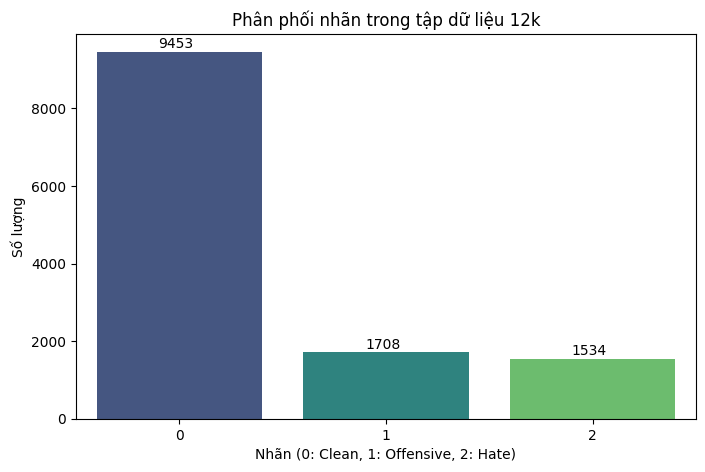

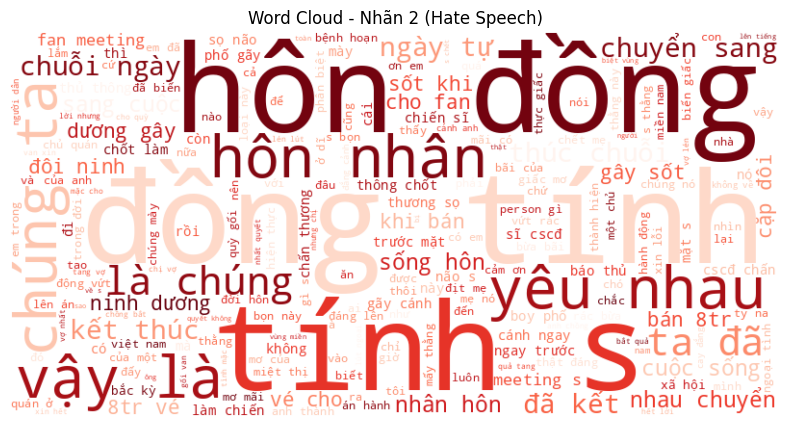

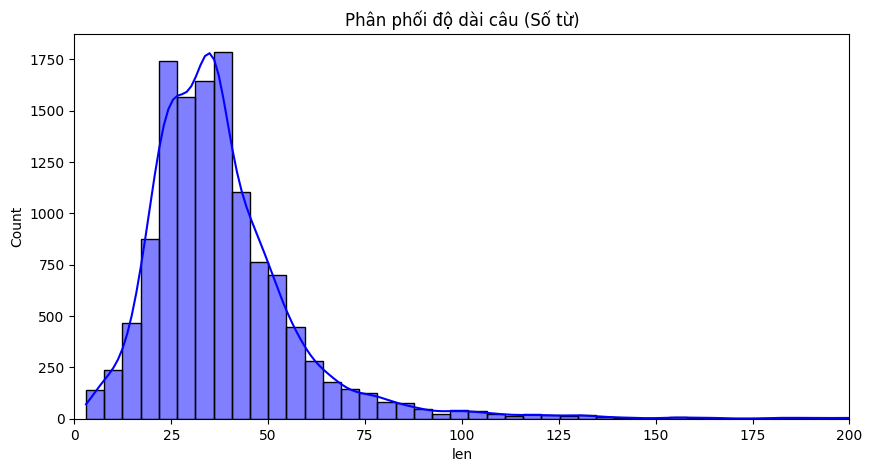

In [ ]:
# ======================================================
# PHÂN TÍCH & VISUALIZE DATASET CUỐI CÙNG
# ======================================================

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# 1. Load data (12,695 samples)
df = pd.read_csv("final_dataset_relaxed.csv")

print("="*70)
print("📊 THỐNG KÊ DATASET CUỐI CÙNG")
print("="*70)
print(f"Tổng số mẫu: {len(df):,}")
print(f"\nPhân bố nhãn:")
for label, count in sorted(df['label'].value_counts().items()):
    pct = count / len(df) * 100
    label_name = ['Clean', 'Offensive', 'Hate Speech'][label]
    print(f"  Label {label} ({label_name:15s}): {count:5,} ({pct:5.1f}%)")
print("="*70)

# 2. Biểu đồ phân phối nhãn
plt.figure(figsize=(10, 6))
labels_name = ['Label 0\n(Clean)', 'Label 1\n(Offensive)', 'Label 2\n(Hate Speech)']
counts = [df[df['label']==i].shape[0] for i in range(3)]
colors = ['#2ecc71', '#f39c12', '#e74c3c']

ax = plt.bar(labels_name, counts, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
plt.title('Phân Phối Nhãn trong Dataset 12,695 Samples', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nhãn', fontsize=13, fontweight='bold')
plt.ylabel('Số lượng mẫu', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Thêm số liệu trên mỗi cột
for i, (label, count) in enumerate(zip(labels_name, counts)):
    pct = count / len(df) * 100
    plt.text(i, count + 200, f'{count:,}\n({pct:.1f}%)', 
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 3. Word Cloud cho từng nhãn
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
label_names = ['Clean', 'Offensive', 'Hate Speech']
colormaps = ['Greens', 'Oranges', 'Reds']

for i, (ax, name, cmap) in enumerate(zip(axes, label_names, colormaps)):
    text_data = " ".join(df[df['label']==i]['input_text'].astype(str))
    wc = WordCloud(width=600, height=400, background_color='white', 
                   colormap=cmap, max_words=50).generate(text_data)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Label {i} - {name}', fontsize=14, fontweight='bold', pad=10)

plt.suptitle('Word Cloud - Top 50 từ phổ biến theo nhãn', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 4. Biểu đồ độ dài câu (số từ)
df['len'] = df['input_text'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 6))
for i, (name, color) in enumerate(zip(label_names, colors)):
    data = df[df['label']==i]['len']
    plt.hist(data, bins=50, alpha=0.6, label=f'Label {i} ({name})', color=color, edgecolor='black')

plt.title('Phân Phối Độ Dài Câu (Số Từ) Theo Nhãn', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Số từ', fontsize=13, fontweight='bold')
plt.ylabel('Tần suất', fontsize=13, fontweight='bold')
plt.xlim(0, 200)  # Zoom vào phần chính
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# 5. Thống kê độ dài
print("\n📏 Thống kê độ dài câu (số từ):")
print("="*70)
print(f"Min:  {df['len'].min()}")
print(f"Max:  {df['len'].max()}")
print(f"Mean: {df['len'].mean():.1f}")
print(f"Median: {df['len'].median():.1f}")
print("="*70)

# 6. So sánh độ dài trung bình theo nhãn
print("\n📊 Độ dài trung bình theo nhãn:")
for i, name in enumerate(label_names):
    avg_len = df[df['label']==i]['len'].mean()
    print(f"  Label {i} ({name:15s}): {avg_len:.1f} từ")
print("="*70)

# 📋 TỔNG KẾT TOÀN BỘ PIPELINE

## ✅ Kết quả đạt được:

### 🎯 Giai đoạn 1: Gold Standard Dataset
- **Input**: 1,127 samples (manually labeled with context)
- **Distribution**: 
  - Label 0 (Clean): 467 samples (41.4%)
  - Label 1 (Offensive): 289 samples (25.7%)
  - Label 2 (Hate Speech): 371 samples (32.9%)
- **Quality**: ⭐⭐⭐⭐⭐ Human verified

### 🤖 Giai đoạn 2: Teacher Model Training
- **Model**: PhoBERT-base-v2 (vinai/phobert-base-v2)
- **Training Setup**:
  - Max length: 256 tokens
  - Batch size: 16
  - Learning rate: 2e-5
  - Epochs: 5
  - Loss: CrossEntropyLoss with Class Weights [0.8048, 1.3000, 1.0120]
- **Results**:
  - Train Loss: 0.989 → 0.403 (converged)
  - Val Loss: 0.874 → 0.540 (improved steadily)
  - Train/Test Split: 90/10 (~1014 train, ~113 test)

### 🏷️ Giai đoạn 3: Pseudo-labeling
- **Unlabeled Pool**: 17,753 samples
- **Prediction Time**: ~4 minutes (555 batches, batch_size=32)

#### Option 1: Threshold 0.9 (Super High Quality)
- **Accepted**: 2,130 samples (12.0%)
- **Rejected**: 15,623 samples (88.0%)
- **Final Dataset**: 3,257 rows
- **Use Case**: Demo, báo cáo, evaluation

#### Option 2: Threshold 0.75 (Production Ready) ✅
- **Accepted**: 11,568 samples (65.2%)
- **Rejected**: 6,185 samples (34.8%)
- **Final Dataset**: 12,695 rows
- **Distribution**:
  - Label 0: 9,453 (74.5%)
  - Label 1: 1,708 (13.5%)
  - Label 2: 1,534 (12.1%)
- **Use Case**: Train production model

## 🎯 Next Steps:

1. **Train Production Model** với 12,695 samples
2. **Apply Techniques**:
   - Class Weights để xử lý imbalance
   - Data Augmentation cho Label 1 & 2
   - Ensemble methods (nếu cần)
3. **Evaluation**: Test trên hold-out set độc lập
4. **Deployment**: API endpoint cho real-time detection
5. **Monitoring**: Track performance và retrain định kỳ

## 📁 Files Generated:

```
✅ final_dataset_18k.csv      (3,257 rows, threshold 0.9)
✅ final_dataset_relaxed.csv  (12,695 rows, threshold 0.75) ← MAIN
✅ teacher_model_final/       (PhoBERT-v2 checkpoint)
```

## ⚠️ Lưu ý quan trọng:

1. **Imbalance Issue**: Dataset nghiêng về Label 0 (74.5%)
   - **Solution**: PHẢI dùng Class Weights khi train
   
2. **Context Coverage**: 96.1% samples có Post Title
   - Đảm bảo luôn có context khi inference
   
3. **Quality Control**: Chỉ chấp nhận samples có confidence ≥ 0.75
   - Loại bỏ vùng xám (uncertain predictions)
   
4. **Model Limitation**: PhoBERT max 256 tokens
   - Long comments bị truncate → Cân nhắc preprocessing

---

**🎉 Pipeline hoàn thành! Sẵn sàng cho production training!**

In [ ]:
# ======================================================
# DOWNLOAD FILES VỀ MÁY LOCAL
# ======================================================

from google.colab import files
import os

print("="*70)
print("📥 CHUẨN BỊ DOWNLOAD FILES")
print("="*70)

# Kiểm tra files tồn tại
files_to_check = [
    "final_dataset_18k.csv",
    "final_dataset_relaxed.csv",
    "training_data_final_merged.csv"
]

print("\n✅ Files available for download:")
for f in files_to_check:
    if os.path.exists(f):
        size_mb = os.path.getsize(f) / (1024*1024)
        print(f"   - {f:40s} ({size_mb:.2f} MB)")
    else:
        print(f"   - {f:40s} (NOT FOUND)")

print("\n" + "="*70)
print("📌 CHỌN FILE CẦN DOWNLOAD:")
print("="*70)

# Download file chính (threshold 0.75) - Production ready
print("\n1. Downloading: final_dataset_relaxed.csv (12,695 rows - MAIN)")
if os.path.exists("final_dataset_relaxed.csv"):
    files.download("final_dataset_relaxed.csv")
    print("   ✅ Downloaded!")
else:
    print("   ❌ File not found!")

# Download file threshold 0.9 (optional)
print("\n2. Downloading: final_dataset_18k.csv (3,257 rows - High Quality)")
if os.path.exists("final_dataset_18k.csv"):
    files.download("final_dataset_18k.csv")
    print("   ✅ Downloaded!")
else:
    print("   ❌ File not found!")

print("\n" + "="*70)
print("🎉 HOÀN TẤT! Kiểm tra Downloads folder của bạn.")
print("="*70)

# In hướng dẫn sử dụng
print("\n📖 HƯỚNG DẪN SỬ DỤNG:")
print("-" * 70)
print("1. File 'final_dataset_relaxed.csv' (12,695 rows):")
print("   → Dùng để train PRODUCTION MODEL")
print("   → Đảm bảo apply Class Weights: [0.8048, 1.3000, 1.0120]")
print("")
print("2. File 'final_dataset_18k.csv' (3,257 rows):")
print("   → Dùng cho Demo, Evaluation")
print("   → Quality cao hơn (threshold 0.9)")
print("-" * 70)